In [16]:
import numpy as np
from nn.nn import NeuralNetwork
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.io import read_text_file, read_fasta_file

import matplotlib.pyplot as plt

### **Load in, Balance, One-Hot Encode, and Split Dataset**

*Choice of Sampling Scheme:*
I chose to oversample the minority class (in my implementation of sample_seqs) in order to avoid missing out on the useful, heterogeneous data from the majority class. 

In [17]:
# load positive and negative motifs
pos_seqs = read_text_file("data/rap1-lieb-positives.txt")

neg_seqs_full = read_fasta_file("data/yeast-upstream-1k-negative.fa")
neg_seqs = [seq[:len(pos_seqs[0])] for seq in neg_seqs_full] # shortening neg_seqs to be same len as pos seqs

X_unbal = pos_seqs + neg_seqs
y_unbal = np.array([True] * len(pos_seqs) + [False] * len(neg_seqs))
print(f"Dataset includes {len(pos_seqs)} postive and {len(neg_seqs)} negative motifs.")

# balance dataset
X, y = sample_seqs(seqs=X_unbal, labels=y_unbal)
print(f"Balanced dataset now includes {sum(y)} postive and {len(y)-sum(y)} negative motifs.")

# turn dataset into formatted arrays
X = np.array(X)
y = np.array(y).astype(int) # changing False/True into 0/1

# encode seq array
X = one_hot_encode_seqs(X)

Dataset includes 137 postive and 3163 negative motifs.
Balanced dataset now includes 3163 postive and 3163 negative motifs.


In [18]:
# splitting digits into train and validation
validation_prop = 0.20

num_samples = X.shape[0]
validation_size = int(validation_prop * num_samples)

random_indices = np.random.permutation(num_samples)

val_idx = random_indices[:validation_size]
train_idx = random_indices[validation_size:]

X_train = X[train_idx]
y_train = y[train_idx].reshape([-1, 1]) # correcting shape from (a,) -> (a, 1)
X_val = X[val_idx]
y_val = y[val_idx].reshape([-1, 1])

print(f"Number of Training Examples: {len(y_train)}")
print(f"Number of Validation Examples: {len(y_val)}")

Number of Training Examples: 5061
Number of Validation Examples: 1265


### **Define and Train Transcript Classfier Model**

*Loss Function Choice:*
Because this is a binary classifier, binary cross entropy was a more appropriate pick for the loss function, rather than mean squared error. This is because this loss function is specifically catered towards penalizing how far the predicted probabilities are from true, binary labels. 

*Hyperparameter Choices:* 
Admittedly, some of the hyperparameter choices came from running the model a few times and seeing what caused training/validation loss to trend downwards and final accuracy to increase. However, I generally made the choice to have a learning rate of 0.01 to allow semi-fast convergence without making learning rate so large that the model would keep missing convergence. For batch size, I generally wanted to choose a size that would allow the model to train on enough examples for every given batch, without requiring too much computation, and thus, 128 seemed like a sufficient number to get a pretty good portion, given the size of the training and validation sets. As for epochs, I just ensured to set them high enough so that I could see the training and validation loss to plateau, without seeing a rise in loss that would suggest overfitting. 

*Choice of Architecture:*
Again, this was a bit of trial and error to see what ended up being an ideal architecture, but the general premise was to create an architecture that would first expand in layer size to try and extrapolate as much information as possible from the input, before narrowing the layer sizes into the final single-neuron layer, which must contain one neuron to create the singular classification prediction value that the model must output. 

In [19]:
input_size = X_train.shape[1] # X_train.shape = (num samples, num features)

classifier_arch =  [
    {"input_dim": input_size, "output_dim": 512, "activation": "relu"},
    {"input_dim": 512, "output_dim": 128, "activation": "relu"},
    {"input_dim": 128, "output_dim": 1, "activation": "sigmoid"}
]

transcript_classifier = NeuralNetwork(
    nn_arch = classifier_arch,
    lr = 0.01,
    seed = 29,
    batch_size = 128,
    epochs = 100,
    loss_function = "bce"
)

In [20]:
train_losses, val_losses = transcript_classifier.fit(X_train, y_train,
                                                     X_val, y_val)

### **Visualize Training and Validation Loss**

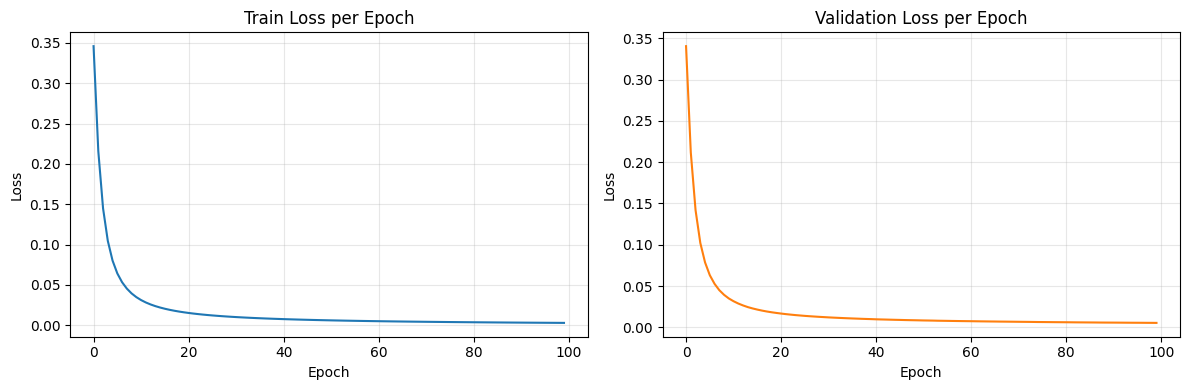

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(train_losses, color="tab:blue")
axes[0].set_title("Train Loss per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True, alpha=0.3)

axes[1].plot(val_losses, color="tab:orange")
axes[1].set_title("Validation Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### **Report Accuracy of Model on Validation Set**

In [22]:
y_hat = transcript_classifier.predict(X_val).flatten()
y_hat = (y_hat >= 0.5).astype(int) # turning output values to actual predictions

y_true = y_val.flatten()

acc = np.sum(y_hat == y_true) / len(y_true)
print(f"Validation Accuracy: {round(acc, 4)}")


Validation Accuracy: 0.9976
